In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import dataset loader from Hugging Face
from datasets import load_dataset

# Import train-test split function
from sklearn.model_selection import train_test_split

# Import feature scaling method
from sklearn.preprocessing import StandardScaler

# Import Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

# Import library to save model
import joblib

In [2]:
# Load dataset from Hugging Face
dataset = load_dataset("sanadf234/Heart-Disease-Prediction-dataset")

# Convert dataset into pandas dataframe
df = dataset['train'].to_pandas()

# Display first 5 rows
df.head()

,id,age,gender,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,slope,thal,heart_disease
0,1,77,Female,Non-Anginal Pain,120,542,0,Left Ventricular Hypertrophy,185,No,3.9,Upsloping,Reversible Defect,1
1,2,51,Female,Asymptomatic,192,423,1,ST-T Wave Abnormality,78,No,6.3,Flat,Fixed Defect,1
2,3,79,Female,Atypical Angina,182,557,1,ST-T Wave Abnormality,111,No,4.7,Flat,Normal,1
3,4,74,Male,Typical Angina,102,159,1,Normal,147,No,5.1,Flat,Normal,1
4,5,54,Male,Non-Anginal Pain,183,278,0,ST-T Wave Abnormality,195,Yes,4.3,Upsloping,Normal,1


In [3]:
# Display number of rows and columns
print(df.shape)

# Display dataset information
df.info()

# Display statistical summary
df.describe()

(54897, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54897 entries, 0 to 54896
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   54897 non-null  int64  
 1   age                  54897 non-null  int64  
 2   gender               54897 non-null  object 
 3   chest_pain_type      54897 non-null  object 
 4   resting_bp           54897 non-null  int64  
 5   cholesterol          54897 non-null  int64  
 6   fasting_blood_sugar  54897 non-null  int64  
 7   resting_ecg          54897 non-null  object 
 8   max_heart_rate       54897 non-null  int64  
 9   exercise_angina      54897 non-null  object 
 10  oldpeak              54897 non-null  float64
 11  slope                54897 non-null  object 
 12  thal                 54897 non-null  object 
 13  heart_disease        54897 non-null  int64  
dtypes: float64(1), int64(7), object(6)
memory usage: 5.9+ MB


,id,age,resting_bp,cholesterol,fasting_blood_sugar,max_heart_rate,oldpeak,heart_disease
count,54897.000000,54897.000000,54897.000000,54897.000000,54897.000000,54897.000000,54897.000000,54897.000000
mean,27449.000000,53.987012,140.090970,349.458750,0.499481,130.731989,3.238667,0.788495
std,15847.543201,21.100459,34.984844,144.254318,0.500004,41.372311,1.876753,0.408379
min,1.000000,18.000000,80.000000,100.000000,0.000000,60.000000,0.000000,0.000000
25%,13725.000000,36.000000,110.000000,224.000000,0.000000,95.000000,1.600000,1.000000
50%,27449.000000,54.000000,140.000000,350.000000,0.000000,131.000000,3.200000,1.000000
75%,41173.000000,72.000000,171.000000,474.000000,1.000000,166.000000,4.900000,1.000000
max,54897.000000,90.000000,200.000000,600.000000,1.000000,202.000000,6.500000,1.000000


In [4]:
# Check missing values in dataset
df.isnull().sum()

id                     0
age                    0
gender                 0
chest_pain_type        0
resting_bp             0
cholesterol            0
fasting_blood_sugar    0
resting_ecg            0
max_heart_rate         0
exercise_angina        0
oldpeak                0
slope                  0
thal                   0
heart_disease          0
dtype: int64

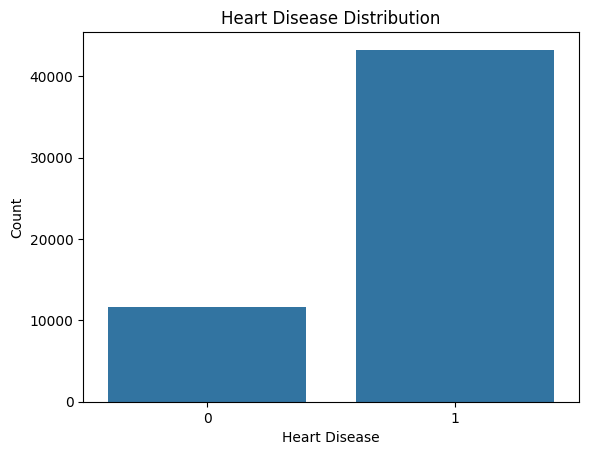

In [5]:
# Visualize target class distribution
sns.countplot(x='heart_disease', data=df)

# Add plot title
plt.title("Heart Disease Distribution")

# Add x-axis label
plt.xlabel("Heart Disease")

# Add y-axis label
plt.ylabel("Count")

# Display plot
plt.show()

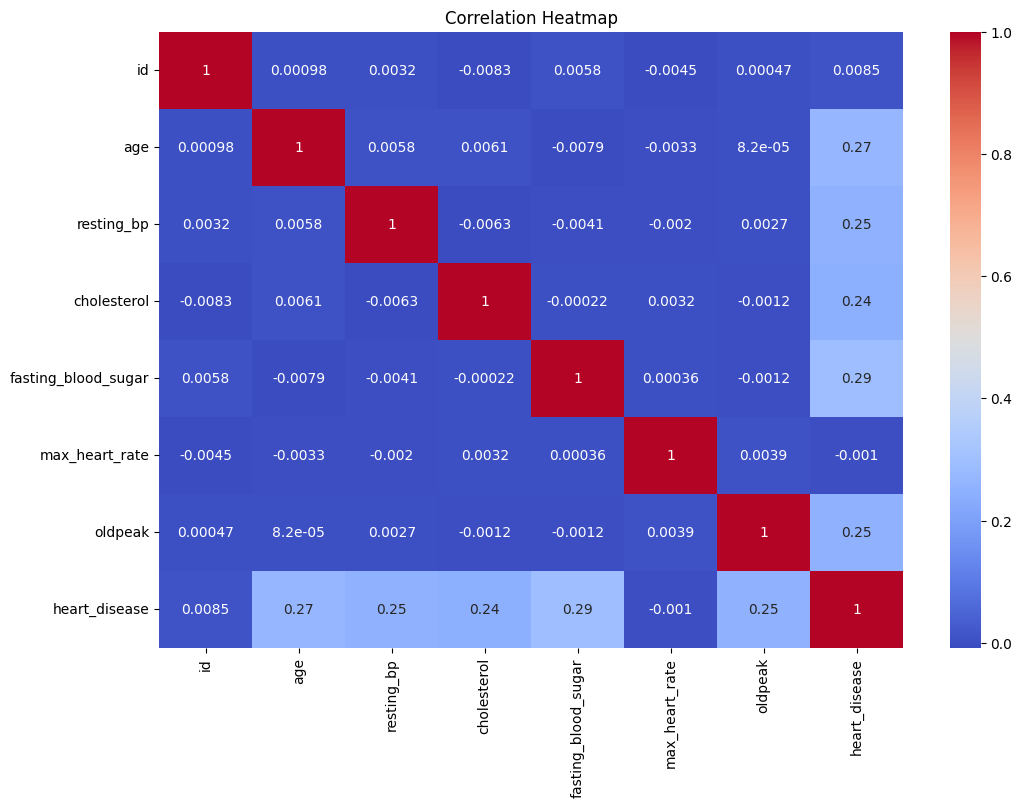

In [6]:
# Create correlation heatmap for numerical features
plt.figure(figsize=(12,8))

# Plot heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

# Add title
plt.title("Correlation Heatmap")

# Display heatmap
plt.show()

In [7]:
# Separate input features and target column
X = df.drop("heart_disease", axis=1)

# Store target values
y = df["heart_disease"]

In [8]:
# Convert categorical columns into numerical format
X = pd.get_dummies(X, drop_first=True)

# Display first 5 rows after encoding
X.head()

,id,age,resting_bp,cholesterol,fasting_blood_sugar,max_heart_rate,oldpeak,gender_Male,chest_pain_type_Atypical Angina,chest_pain_type_Non-Anginal Pain,chest_pain_type_Typical Angina,resting_ecg_Normal,resting_ecg_ST-T Wave Abnormality,exercise_angina_Yes,slope_Flat,slope_Upsloping,thal_Normal,thal_Reversible Defect
0,1,77,120,542,0,185,3.9,False,False,True,False,False,False,False,False,True,False,True
1,2,51,192,423,1,78,6.3,False,False,False,False,False,True,False,True,False,False,False
2,3,79,182,557,1,111,4.7,False,True,False,False,False,True,False,True,False,True,False
3,4,74,102,159,1,147,5.1,True,False,False,True,True,False,False,True,False,True,False
4,5,54,183,278,0,195,4.3,True,False,True,False,False,True,True,False,True,True,False


In [9]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
# Create scaler object
scaler = StandardScaler()

# Fit and transform training data
X_train = scaler.fit_transform(X_train)

# Transform testing data
X_test = scaler.transform(X_test)

In [11]:
# Create Logistic Regression model
model = LogisticRegression()

# Train model using training data
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [12]:
# Predict values for test dataset
y_pred = model.predict(X_test)

In [13]:
# Calculate model accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print accuracy score
print("Accuracy :", accuracy)

Accuracy : 0.9123861566484517


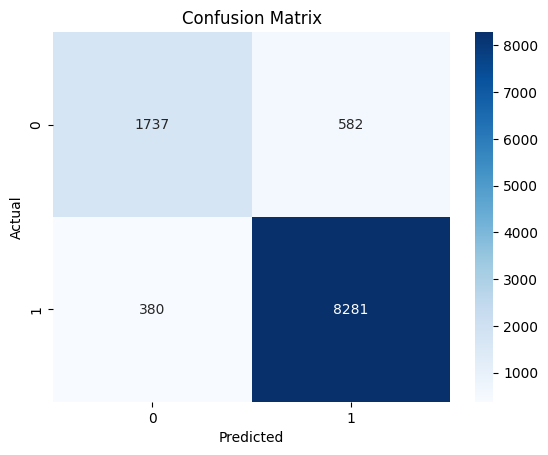

In [14]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix using heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# Add title
plt.title("Confusion Matrix")

# Add x-axis label
plt.xlabel("Predicted")

# Add y-axis label
plt.ylabel("Actual")

# Display plot
plt.show()

In [15]:
# Display classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.75      0.78      2319
           1       0.93      0.96      0.95      8661

    accuracy                           0.91     10980
   macro avg       0.88      0.85      0.86     10980
weighted avg       0.91      0.91      0.91     10980



In [16]:
# Calculate ROC-AUC score
roc_score = roc_auc_score(y_test, y_pred)

# Print ROC-AUC score
print("ROC-AUC Score :", roc_score)

ROC-AUC Score : 0.8525774564810239


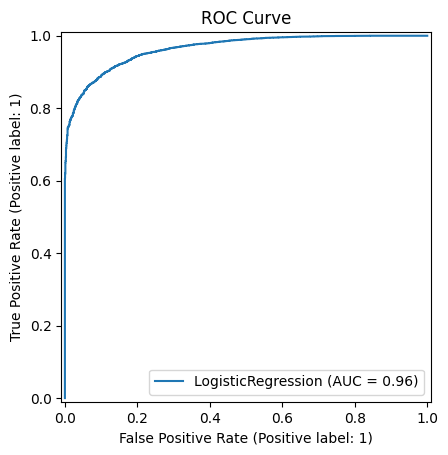

In [17]:
# Plot ROC Curve
RocCurveDisplay.from_estimator(model, X_test, y_test)

# Add title
plt.title("ROC Curve")

# Display curve
plt.show()

In [18]:
# Save trained model
joblib.dump(model, "../models/logistic_regression_model.pkl")

# Save scaler object
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [19]:
# Create sample input data for prediction
sample_data = X.iloc[0:1]

# Scale sample data
sample_data_scaled = scaler.transform(sample_data)

# Predict heart disease
prediction = model.predict(sample_data_scaled)

# Display prediction result
print("Prediction :", prediction)

Prediction : [1]
